# Assignment 1 - Exploratory Data Analysis (EDA)
## Global Shark Attack Incidents

**Course:** Introduction to Data Science  
**Lecturer:** Dr. Uri Itai  
**Teaching Assistant:** Hanit Ohayon Haddad  
**Student name:** Isabel Kriheli
**Student ID:** 323922112 
**Submission date:** 12/8/2026

## 1. Dataset Selection and Source

I chose the shark attack dataset from Kaggle because I found the topic interesting and because the file meets the assignment requirements:

- It contains more than 1,000 rows.
- It contains more than 10 columns.
- It includes numerical, categorical, and time-related variables.

### Data source
The dataset is based on the Global Shark Attack File (GSAF), which collects historical reports of shark-human incidents. The version used in this notebook was downloaded from Kaggle.

**First Published Date:** Jun 10, 2021
**Publisher:** Shruti Prabhu

### Purpose of the data
The purpose of the dataset is to document reported incidents and store details such as the date, country, activity, victim information, injury, and outcome.

### First impression
The dataset contains useful information, but it does not include a full data dictionary. Because of this, some columns are not completely clear at first and need to be examined during the analysis.


## 2. Environment and Imports

The following cell imports the libraries used in the notebook and defines the file paths.


In [1]:
from pathlib import Path
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu

# Set up matplotlib and seaborn plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

DATA_PATH = Path("data/attacks.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)



## 3. Meta-Analysis of the File

Before cleaning the data, I first checked the basic properties of the file.

- **File name:** `attacks.csv`
- **File format:** CSV
- **File size:** approximately 2.85 MB
- **Original creation date:** 2021
- **Purpose:** storing historical records of reported shark-human incidents

### 3.1 Initial Load

The file is loaded into a pandas DataFrame. I display the shape and the first rows to make sure that it was loaded correctly and to get a first look at the data.


In [2]:
raw_df = pd.read_csv(DATA_PATH, encoding="latin1")
print(f"Raw shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
raw_df.head()


Raw shape: 25614 rows, 22 columns


,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Fatal (Y/N),Time,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order
0,2017.06.11,2017-06-11,2017.0,Unprovoked,AUSTRALIA,Western Australia,"Point Casuarina, Bunbury",Body boarding,Paul Goff,M,...,N,08h30,"White shark, 4 m","WA Today, 6/11/2017",2017.06.11-Goff.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.11,2017.06.11,6095.0
1,2017.06.10.b,2017-06-10,2017.0,Unprovoked,AUSTRALIA,Victoria,"Flinders, Mornington Penisula",Surfing,female,F,...,N,15h45,7 gill shark,NaN,2017.06.10.b-Flinders.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.10.b,2017.06.10.b,6094.0
2,2017.06.10.a,2017-06-10,2017.0,Unprovoked,USA,Florida,"Ponce Inlet, Volusia County",Surfing,Bryan Brock,M,...,N,10h00,NaN,"Daytona Beach News-Journal, 6/10/2017",2017.06.10.a-Brock.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.10.a,2017.06.10.a,6093.0
3,2017.06.07.R,Reported 07-Jun-2017,2017.0,Unprovoked,UNITED KINGDOM,South Devon,Bantham Beach,Surfing,Rich Thomson,M,...,N,NaN,"3m shark, probably a smooth hound","C. Moore, GSAF",2017.06.07.R-Thomson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.07.R,2017.06.07.R,6092.0
4,2017.06.04,2017-06-04,2017.0,Unprovoked,USA,Florida,"Middle Sambo Reef off Boca Chica, Monroe County",Spearfishing,Parker Simpson,M,...,N,NaN,8' shark,"Nine News, 6/7/2017",2017.06.04-Simpson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.04,2017.06.04,6091.0


### 3.2 Column Names, Data Types, and Structure

I use `info()` and a small summary table to check the column names, data types, and number of non-missing values.


In [3]:
# Print columns, their types, and non-null counts
raw_df.info()

print("\nRaw column names:")
print(list(raw_df.columns))



<class 'pandas.DataFrame'>
RangeIndex: 25614 entries, 0 to 25613
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Case Number             6095 non-null   str    
 1   Date                    6094 non-null   str    
 2   Year                    6092 non-null   float64
 3   Type                    6090 non-null   str    
 4   Country                 6048 non-null   str    
 5   Area                    5682 non-null   str    
 6   Location                5583 non-null   str    
 7   Activity                5559 non-null   str    
 8   Name                    5888 non-null   str    
 9   Sex                     5517 non-null   str    
 10  Age                     3374 non-null   str    
 11  Injury                  6066 non-null   str    
 12  Fatal (Y/N)             6064 non-null   str    
 13  Time                    2848 non-null   str    
 14  Species                 3100 non-null   str    
 

### 3.3 Initial Structural Observations

From the first inspection, I noticed several issues:

1. Columns such as `Age`, `Date`, and `Time` were loaded as text, so they cannot be analyzed numerically yet.
2. Some column names contain extra spaces, for example `Sex ` and `Species `.
3. `Case Number.1` and `Case Number.2` appear to repeat the original case number.
4. Columns such as `pdf`, `href`, and `href formula` mainly contain links and are not useful for most statistical analyses.
5. `original_order` appears to represent the original spreadsheet order rather than a measured feature.


### 3.4 Record Boundary and Structural Cleaning

The raw file includes many empty rows and several inconsistent column names. In this step, I rename the columns and keep only rows that contain information about an incident.


In [4]:
# Rename columns to standard lowercase names
standard_columns = [
    "case_number", "date", "year", "type", "country", "area", "location",
    "activity", "name", "sex", "age", "injury", "fatal", "time", "species",
    "investigator_or_source", "pdf", "href_formula", "href", "case_number_1",
    "case_number_2", "original_order"
]

working_df = raw_df.copy()
working_df.columns = standard_columns

# Strip whitespace from string columns
for col in working_df.select_dtypes(include="object").columns:
    working_df[col] = working_df[col].str.strip().replace("", np.nan)

# Check completely empty rows
empty_rows_count = working_df.isna().all(axis=1).sum()
print("Number of completely empty rows:", empty_rows_count)

# Drop rows that are completely empty
records_df = working_df.dropna(how="all").copy()

# Keep only rows that have both a case number and date (actual incidents)
records_df = records_df[records_df["case_number"].notna() & records_df["date"].notna()]
print(f"Remaining event records: {len(records_df)}")



Number of completely empty rows: 19518
Remaining event records: 6094


C:\Users\izabe\AppData\Local\Temp\ipykernel_24112\480343407.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in working_df.select_dtypes(include="object").columns:


### Decision About Empty Rows

The raw file contains 19,518 completely empty rows, mainly at the bottom of the spreadsheet. These rows do not represent incidents, so I removed them.

After removing the empty and unusable rows, the analytical dataset contains **6,094 records and 22 original columns**.


### 3.5 Feature Engineering and Cleaning

Some variables need to be converted before they can be analyzed. In this section, I create cleaned versions of age, time, sex, fatality status, incident type, and date-related variables.


In [5]:
# Clean Age column: extract numbers only, ignore ranges/vague text
def clean_age(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip().lower()
    match = re.search(r"\d+", val_str)
    if match:
        age = int(match.group())
        if 0 < age < 100:
            return float(age)
    return np.nan

# Clean Time column: extract decimal hour from various formats
def clean_time(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip().lower()
    
    # Check 14h30 or 14:30
    match = re.search(r"(\d{1,2})[h:](\d{2})?", val_str)
    if match:
        hour = int(match.group(1))
        minutes = int(match.group(2)) / 60.0 if match.group(2) else 0.0
        if 0 <= hour < 24:
            return float(hour + minutes)
            
    # Check 1400
    match_compact = re.fullmatch(r"(\d{2})(\d{2})", val_str)
    if match_compact:
        hour = int(match_compact.group(1))
        minutes = int(match_compact.group(2)) / 60.0
        if 0 <= hour < 24:
            return float(hour + minutes)

    # Check 2 pm or 11 am
    match_ampm = re.search(r"(\d{1,2})\s*(am|pm)", val_str)
    if match_ampm:
        hour = int(match_ampm.group(1))
        ampm = match_ampm.group(2)
        if ampm == "pm" and hour < 12:
            hour += 12
        elif ampm == "am" and hour == 12:
            hour = 0
        if 0 <= hour < 24:
            return float(hour)
            
    return np.nan

analysis_df = records_df.copy()
analysis_df["age_numeric"] = analysis_df["age"].apply(clean_age)
analysis_df["hour_numeric"] = analysis_df["time"].apply(clean_time)

# Clean date column
analysis_df["date_iso_raw"] = pd.to_datetime(analysis_df["date"], format="%Y-%m-%d", errors="coerce")
# Only keep parsed date if its year matches the 'year' column
mask = analysis_df["date_iso_raw"].dt.year == analysis_df["year"]
analysis_df["parsed_date"] = analysis_df["date_iso_raw"].where(mask)
analysis_df["month"] = analysis_df["parsed_date"].dt.month

# Standardize Sex and Fatality
analysis_df["sex_clean"] = analysis_df["sex"].str.strip().str.upper().map({"M": "Male", "F": "Female"}).fillna("Unknown")
analysis_df["fatal_clean"] = analysis_df["fatal"].str.strip().str.upper().map({"Y": "Fatal", "N": "Non-fatal"}).fillna("Unknown")
analysis_df["fatal_binary"] = analysis_df["fatal_clean"].map({"Fatal": 1, "Non-fatal": 0})

# Standardize Type (merge Boat and Boating)
analysis_df["type_clean"] = analysis_df["type"].str.strip().replace("Boat", "Boating").fillna("Unknown")

# Create categories
analysis_df["year_valid"] = analysis_df["year"].where(analysis_df["year"].between(1500, 2017))
analysis_df["decade"] = (analysis_df["year_valid"] // 10 * 10).astype("Int64")

analysis_df["age_group"] = pd.cut(
    analysis_df["age_numeric"],
    bins=[0, 12, 18, 30, 45, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Middle-aged", "Senior"]
)

analysis_df["time_period"] = pd.cut(
    analysis_df["year"],
    bins=[0, 1900, 1950, 1980, 2000, 2018],
    labels=["Before 1900", "1900-1949", "1950-1979", "1980-1999", "2000-2017"],
    right=False
)

cleaned_path = OUTPUT_DIR / "attacks_cleaned.csv"
analysis_df.to_csv(cleaned_path, index=False, encoding="utf-8")
print(f"Cleaned file saved to {cleaned_path}")
print(f"Rows: {len(analysis_df)}, columns: {analysis_df.shape[1]}")



Cleaned file saved to outputs\attacks_cleaned.csv
Rows: 6094, columns: 35


### Cleaning Decisions

- I kept the original text columns and created new cleaned columns instead of overwriting them.
- For age and time, I extracted usable numerical values when possible.
- A parsed date was kept only when its year was consistent with the separate `year` column.
- I grouped `Boat` and `Boating` into one category because they describe the same general incident type.
- Values that could not be interpreted safely were marked as missing or `Unknown`.


## 4. Data Quality and Completeness

In this section, I examine missing values, duplicate records, suspicious values, and the number of unique values in each column.


### 4.1 Missing Data


,Missing Count,Percentage
time,3251,53.347555
species,3003,49.277978
age,2724,44.699705
sex,577,9.468330
activity,537,8.811946
location,512,8.401707
area,412,6.760748
name,206,3.380374
country,46,0.754841
fatal,30,0.492287


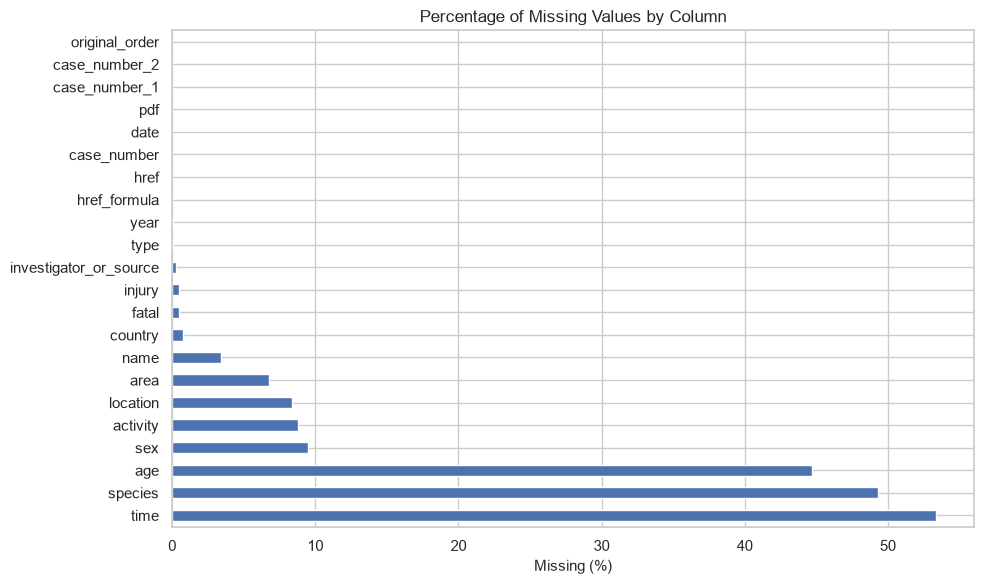

In [6]:
# Calculate missing counts and percentages
missing_counts = analysis_df[standard_columns].isnull().sum()
missing_pct = (analysis_df[standard_columns].isnull().sum() / len(analysis_df)) * 100

missing_df = pd.DataFrame({"Missing Count": missing_counts, "Percentage": missing_pct})
missing_df = missing_df.sort_values(by="Percentage", ascending=False)
display(missing_df)

# Horizontal bar chart of missing values
plt.figure(figsize=(10, 6))
missing_df["Percentage"].plot(kind="barh")
plt.title("Percentage of Missing Values by Column")
plt.xlabel("Missing (%)")
plt.tight_layout()
plt.show()



,age,time,species,sex,location
time_period,,,,,
Before 1900,86.822840,86.822840,81.991215,9.663250,20.937042
1900-1949,67.267552,75.996205,69.829222,10.626186,9.772296
1950-1979,42.897527,58.727915,44.452297,14.558304,9.045936
1980-1999,33.233533,46.706587,36.327345,9.181637,5.588822
2000-2017,24.819401,28.689370,36.790506,5.211558,4.179567


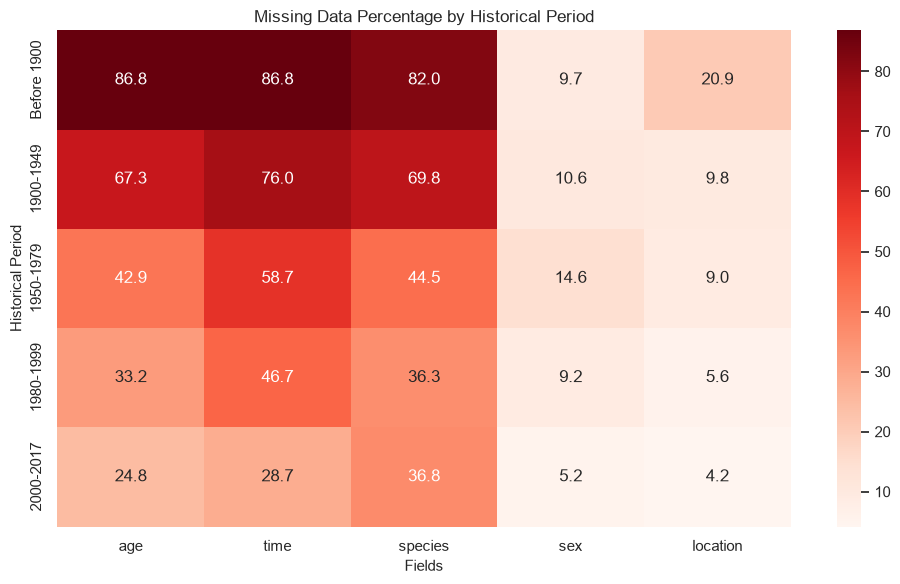

In [7]:
# Group by time period and check missing percent
missing_by_period = analysis_df.groupby("time_period", observed=True).agg({
    "age": lambda x: x.isnull().mean() * 100,
    "time": lambda x: x.isnull().mean() * 100,
    "species": lambda x: x.isnull().mean() * 100,
    "sex": lambda x: x.isnull().mean() * 100,
    "location": lambda x: x.isnull().mean() * 100
})

display(missing_by_period)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(missing_by_period, annot=True, cmap="Reds", fmt=".1f")
plt.title("Missing Data Percentage by Historical Period")
plt.xlabel("Fields")
plt.ylabel("Historical Period")
plt.tight_layout()
plt.show()



### Missing Data Findings

The missing-data heatmap shows that the missing values are not distributed evenly. Older records are much less complete than newer records. For example, age is missing in about 83.5% of records from before 1900, compared with about 24.3% in the 2000-2017 period.

Because the missingness is related to the time period, I would not fill missing ages or times with one overall mean or median. Doing so could create values that do not represent the historical records correctly.

For cleaned categorical variables, unclear or missing values are kept as `Unknown` so that the missing information remains visible in the analysis.


### 4.2 Duplicates


In [8]:
# Check for completely identical rows
print("Full duplicates:", analysis_df[standard_columns].duplicated().sum())

# Check for duplicate case numbers
dup_case_mask = analysis_df.duplicated("case_number", keep=False)
print("Duplicate case numbers count:", dup_case_mask.sum())

# Display some duplicate cases
dup_cases = analysis_df[dup_case_mask].sort_values("case_number")
display(dup_cases[["case_number", "date", "country", "location", "name"]].head(10))



Full duplicates: 0
Duplicate case numbers count: 32


,case_number,date,country,location,name
5294,1907.10.16.R,Reported 16-Oct-1907,CHINA,"Sharp Peak, Sai Kung Peninsula, New Territories",fishermen
5293,1907.10.16.R,Reported 16-Oct-1907,CHINA,"Sharp Peak, Sai Kung Peninsula, New Territories",fishermen
5207,1913.08.27.R,Reported 27-Aug-1913,USA,"Spring Lake, Monmouth County",NaN
5206,1913.08.27.R,Reported 27-Aug-1913,USA,"Lavalette, Ocean County",NaN
5177,1915.07.06.a.R,Reported 06-Jul-1915,MEXICO,Santa Maria Bar,J.W. McDonald
5176,1915.07.06.a.R,Reported 06-Jul-1915,MEXICO,Tampico,Captain Thaxton
5115,1920.00.00.b,1905-04-03,NEW ZEALAND,"Stanley Bay, Auckland Harbor",female
5114,1920.00.00.b,1920s,JAMAICA,Savanna-la-Mar,sailor
5069,1923.00.00.a,1905-04-06,USA,Ocean City (offshore),male
5068,1923.00.00.a,1905-04-06,USA,Ocean City (offshore),male


### Duplicate Findings

No completely identical rows were found. There are repeated case numbers, but a closer look shows that some of them describe different victims from the same incident.

For this reason, I decided not to remove rows only because the case number is repeated. Removing them could delete real victim records.


### 4.3 Suspicious and Impossible Values


In [9]:
# Count weird or placeholder values
print("Year = 0:", (analysis_df["year"] == 0).sum())
print("Year < 1500 (but not 0):", ((analysis_df["year"] > 0) & (analysis_df["year"] < 1500)).sum())
print("Unknown sex records:", (analysis_df["sex_clean"] == "Unknown").sum())
print("Unknown fatality records:", (analysis_df["fatal_clean"] == "Unknown").sum())

print("\nRaw sex value counts:")
print(analysis_df["sex"].value_counts(dropna=False))

print("\nRaw fatal value counts:")
print(analysis_df["fatal"].value_counts(dropna=False))



Year = 0: 124
Year < 1500 (but not 0): 3
Unknown sex records: 580
Unknown fatality records: 127

Raw sex value counts:
sex
M      4908
F       606
NaN     577
lli       1
N         1
.         1
Name: count, dtype: int64

Raw fatal value counts:
fatal
N          4400
Y          1566
UNKNOWN      94
NaN          30
2017          1
F             1
#VALUE!       1
n             1
Name: count, dtype: int64


### Suspicious Value Findings

- There are 124 records with `year = 0`. I treated these as unknown years rather than real dates.
- Some values in the sex and fatality columns contain extra spaces or inconsistent letters, such as `M `, `N `, or lowercase `y`.
- These values were standardized into the cleaned categories `Male`, `Female`, `Fatal`, `Non-fatal`, and `Unknown`.

The suspicious values mainly show that the dataset was collected from historical and manually entered records.


### 4.4 Cardinality


In [10]:
# Check unique values in columns
card_df = pd.DataFrame({
    "Unique Values": analysis_df[standard_columns].nunique(),
    "Non-Null Count": analysis_df[standard_columns].notna().sum()
})
card_df["Ratio"] = card_df["Unique Values"] / card_df["Non-Null Count"]
display(card_df.sort_values(by="Unique Values", ascending=False))



,Unique Values,Non-Null Count,Ratio
original_order,6093,6094,0.999836
pdf,6083,6094,0.998195
href_formula,6082,6093,0.998195
case_number_2,6078,6094,0.997374
case_number,6078,6094,0.997374
case_number_1,6077,6094,0.997210
href,6076,6093,0.997210
date,5197,6094,0.852806
name,5080,5888,0.862772
investigator_or_source,4791,6077,0.788382


### Cardinality Findings

- `case_number`, `pdf`, and `href` have many unique values because they act like identifiers or links.
- `activity` and `species` also have high cardinality because they are open-text fields with many different descriptions.
- The cleaned variables `type_clean`, `sex_clean`, and `fatal_clean` have only a few categories, which makes them easier to compare and visualize.


## 5. Univariate Analysis

In this section, I examine each main variable separately before looking at relationships between variables.


### 5.1 Numerical Variables


In [11]:
# Calculate summary stats manually
numeric_cols = ["year", "age_numeric", "hour_numeric"]
summary = analysis_df[numeric_cols].describe()

# Add skewness
summary.loc["skew"] = analysis_df[numeric_cols].skew()

# Add MAD (Median Absolute Deviation)
mads = []
for col in numeric_cols:
    median_val = analysis_df[col].median()
    mad_val = np.median(np.abs(analysis_df[col].dropna() - median_val))
    mads.append(mad_val)
summary.loc["mad"] = mads

# Add IQR
iqrs = []
for col in numeric_cols:
    q1 = analysis_df[col].quantile(0.25)
    q3 = analysis_df[col].quantile(0.75)
    iqrs.append(q3 - q1)
summary.loc["iqr"] = iqrs

display(summary)



,year,age_numeric,hour_numeric
count,6092.000000,3342.000000,2295.000000
mean,1926.197308,27.237283,13.352520
std,284.366422,13.824582,3.583596
min,0.000000,1.000000,0.500000
25%,1942.000000,17.000000,11.000000
50%,1976.000000,24.000000,13.500000
75%,2004.000000,35.000000,16.000000
max,2017.000000,87.000000,23.500000
skew,-6.439729,1.022130,-0.327905
mad,29.000000,8.000000,2.500000


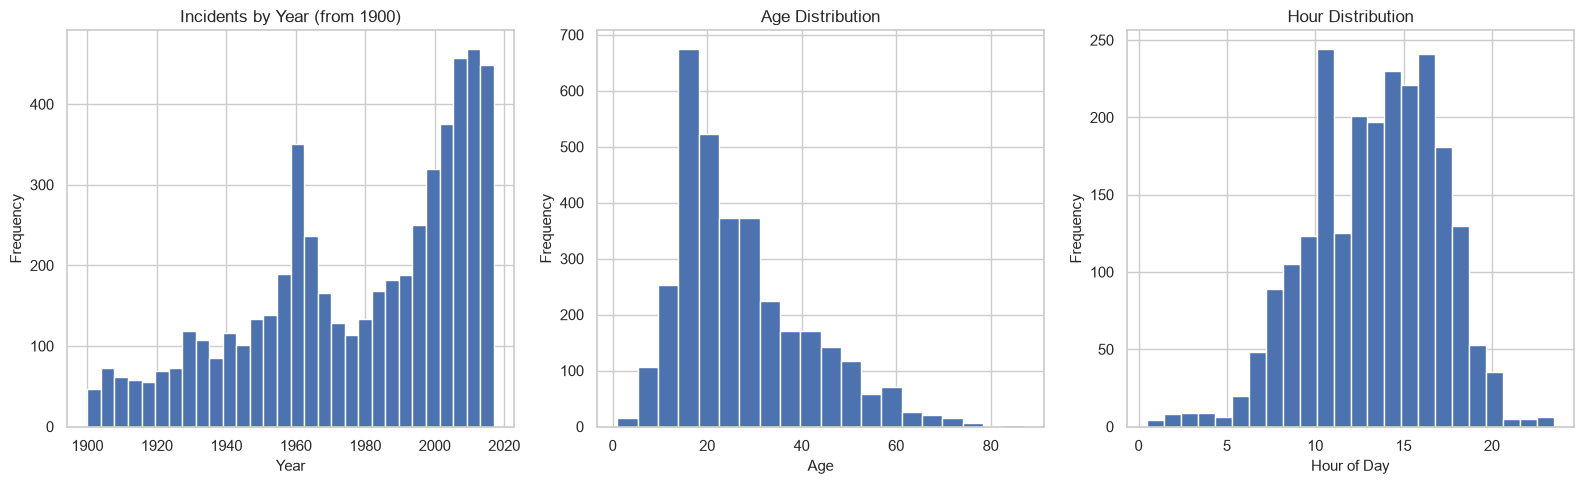

In [12]:
# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Filter years from 1900 to make the plot look better
analysis_df[analysis_df["year"] >= 1900]["year"].plot(kind="hist", bins=30, ax=axes[0])
axes[0].set_title("Incidents by Year (from 1900)")
axes[0].set_xlabel("Year")

analysis_df["age_numeric"].plot(kind="hist", bins=20, ax=axes[1])
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age")

analysis_df["hour_numeric"].plot(kind="hist", bins=24, ax=axes[2])
axes[2].set_title("Hour Distribution")
axes[2].set_xlabel("Hour of Day")

plt.tight_layout()
plt.show()



### Numerical Variable Findings

- **Year:** The distribution is strongly left-skewed because of very old incidents and the placeholder value 0. The number of recorded incidents is much higher in recent decades.
- **Age:** The age distribution is right-skewed. Many of the recorded victims are teenagers or young adults.
- **Hour:** Most incidents with a known time occurred during daytime, especially around midday and the afternoon.

The averages are useful, but they do not describe these variables perfectly because the distributions are skewed and contain missing values and outliers.


### 5.2 Outliers Using Three Methods


In [13]:
# Outlier detection on age using 3 methods
age_data = analysis_df["age_numeric"].dropna()

# Method 1: Z-Score
mean_age = age_data.mean()
std_age = age_data.std()
z_outliers = age_data[np.abs((age_data - mean_age) / std_age) > 3]

# Method 2: IQR
q1 = age_data.quantile(0.25)
q3 = age_data.quantile(0.75)
iqr = q3 - q1
iqr_outliers = age_data[(age_data < q1 - 1.5 * iqr) | (age_data > q3 + 1.5 * iqr)]

# Method 3: Modified Z-Score (using MAD)
median_age = age_data.median()
mad_age = np.median(np.abs(age_data - median_age))
mod_z_scores = 0.6745 * (age_data - median_age) / mad_age
mad_outliers = age_data[np.abs(mod_z_scores) > 3.5]

print("Age outliers:")
print(f"Z-score method found {len(z_outliers)} outliers (min: {z_outliers.min()}, max: {z_outliers.max()})")
print(f"IQR method found {len(iqr_outliers)} outliers (min: {iqr_outliers.min()}, max: {iqr_outliers.max()})")
print(f"Modified Z-score method found {len(mad_outliers)} outliers (min: {mad_outliers.min()}, max: {mad_outliers.max()})")



Age outliers:
Z-score method found 34 outliers (min: 69.0, max: 87.0)
IQR method found 64 outliers (min: 63.0, max: 87.0)
Modified Z-score method found 46 outliers (min: 66.0, max: 87.0)


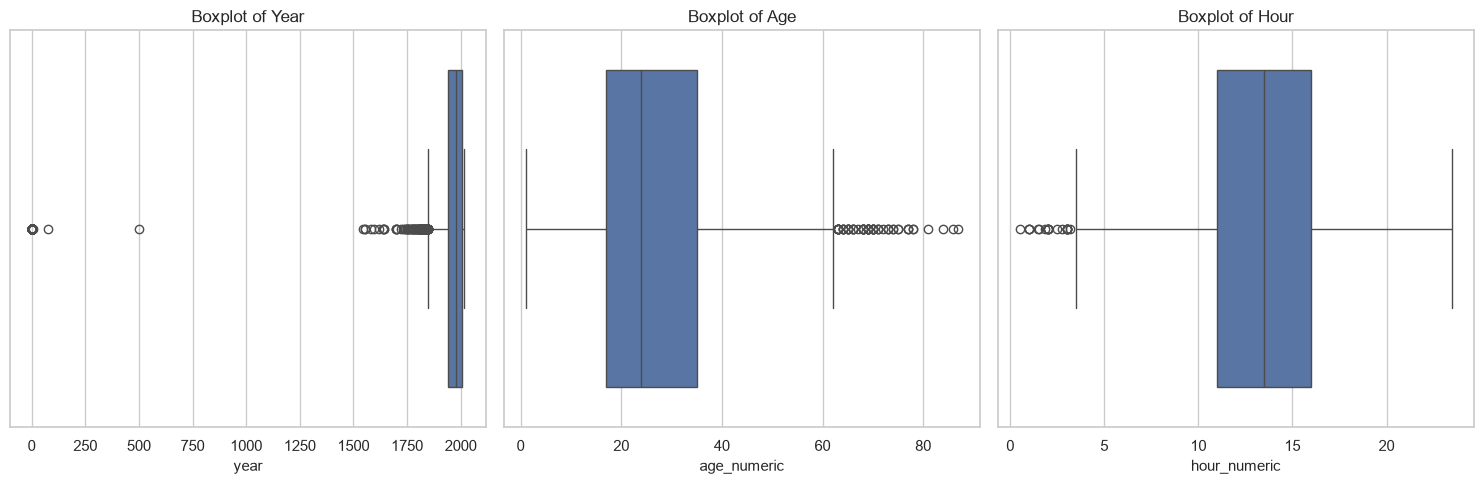

In [14]:
# Boxplots to see outliers visually
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x=analysis_df["year"], ax=axes[0])
axes[0].set_title("Boxplot of Year")

sns.boxplot(x=analysis_df["age_numeric"], ax=axes[1])
axes[1].set_title("Boxplot of Age")

sns.boxplot(x=analysis_df["hour_numeric"], ax=axes[2])
axes[2].set_title("Boxplot of Hour")

plt.tight_layout()
plt.show()



### Outlier Findings

- For `year`, the methods mainly identify year 0 and very early historical records.
- For `age`, the IQR and modified Z-score methods identify older victims as outliers.
- These age values are not necessarily errors. They may be uncommon, but they can still describe real incidents, so I kept them.
- The standard Z-score is less sensitive here because the mean and standard deviation are affected by extreme values. IQR and MAD are more robust for skewed data.


### 5.3 Categorical Variables


In [15]:
# Categorical profiling for key columns
cat_cols = ["country", "activity", "type_clean", "sex_clean", "fatal_clean"]

for col in cat_cols:
    print(f"\n--- Profiling {col} ---")
    counts = analysis_df[col].value_counts(dropna=False)
    pcts = analysis_df[col].value_counts(dropna=False, normalize=True) * 100
    cum_pcts = pcts.cumsum()
    
    display(pd.DataFrame({
        "Count": counts,
        "Percentage": pcts,
        "Cumulative %": cum_pcts
    }).head(10))
    
    # Categories needed for 80% coverage
    k = (cum_pcts <= 80).sum() + 1
    print(f"Number of categories representing 80% of data: {k}")




--- Profiling country ---


,Count,Percentage,Cumulative %
country,,,
USA,2160,35.444700,35.444700
AUSTRALIA,1303,21.381687,56.826387
SOUTH AFRICA,571,9.369872,66.196259
PAPUA NEW GUINEA,133,2.182475,68.378733
NEW ZEALAND,126,2.067607,70.446341
BRAZIL,103,1.690187,72.136528
BAHAMAS,101,1.657368,73.793896
MEXICO,86,1.411224,75.205120
ITALY,71,1.165080,76.370200


Number of categories representing 80% of data: 13

--- Profiling activity ---


,Count,Percentage,Cumulative %
activity,,,
Surfing,935,15.342960,15.342960
Swimming,879,14.424024,29.766984
NaN,537,8.811946,38.578930
Fishing,428,7.023302,45.602232
Spearfishing,332,5.447982,51.050213
Bathing,156,2.559895,53.610108
Wading,146,2.395799,56.005907
Diving,128,2.100427,58.106334
Standing,99,1.624549,59.730883


Number of categories representing 80% of data: 257

--- Profiling type_clean ---


...

Number of categories representing 80% of data: 2

--- Profiling sex_clean ---


,Count,Percentage,Cumulative %
sex_clean,,,
Male,4908,80.538234,80.538234
Female,606,9.944207,90.482442
Unknown,580,9.517558,100.000000


Number of categories representing 80% of data: 1

--- Profiling fatal_clean ---


,Count,Percentage,Cumulative %
fatal_clean,,,
Non-fatal,4401,72.218576,72.218576
Fatal,1566,25.697407,97.915983
Unknown,127,2.084017,100.000000


Number of categories representing 80% of data: 2


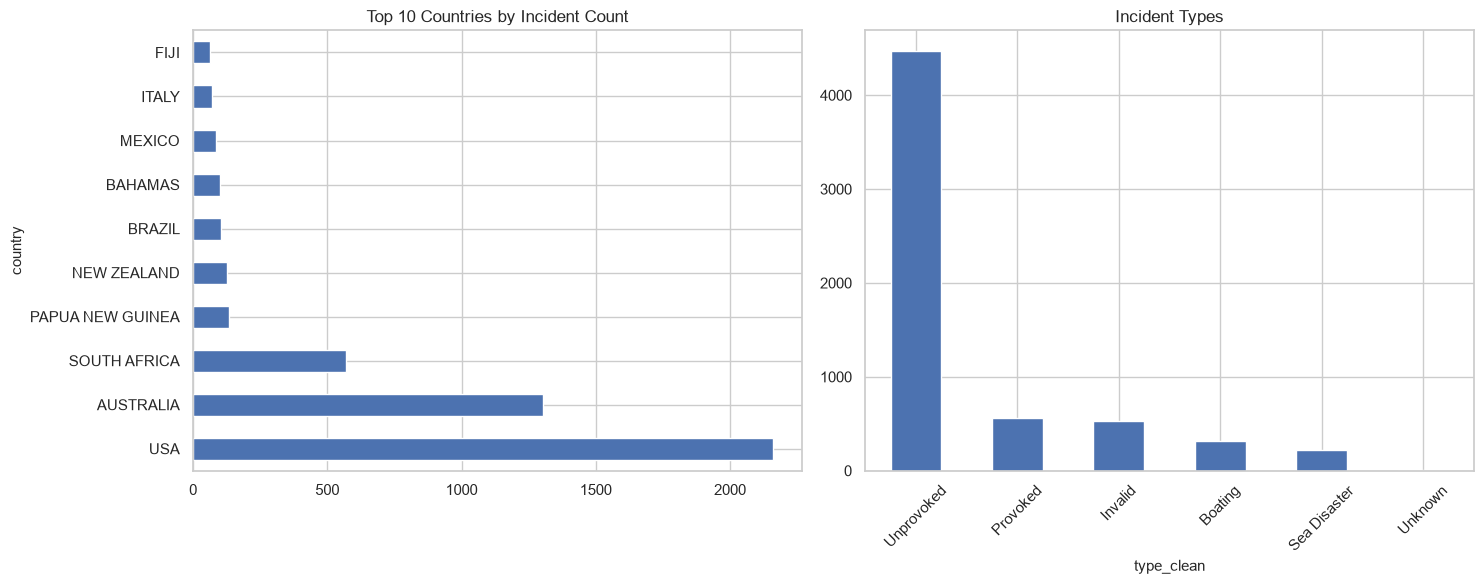

In [16]:
# Plot country and incident type
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

analysis_df["country"].value_counts().head(10).plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 10 Countries by Incident Count")

analysis_df["type_clean"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Incident Types")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



### Categorical Variable Findings

- **Country:** The United States, Australia, and South Africa together represent about 66% of the records.
- **Sex:** Around 89% of records with a known sex are male.
- **Incident type:** Unprovoked incidents are the largest category, representing about 73% of the records.

These percentages describe the documented records, not necessarily the true worldwide distribution. Countries with better reporting systems may appear more often in the dataset.


## 6. Correlations and Relationships

After examining each variable separately, I now check whether some variables are related to each other.


### 6.1 Numerical-Numerical Relationships


In [17]:
# Run correlations
corr_cols = ["year", "age_numeric", "hour_numeric", "original_order"]
corr_df = analysis_df[corr_cols].dropna()

print("Pearson:")
display(corr_df.corr(method="pearson"))

print("\nSpearman:")
display(corr_df.corr(method="spearman"))

print("\nKendall:")
display(corr_df.corr(method="kendall"))



Pearson:


,year,age_numeric,hour_numeric,original_order
year,1.000000,0.107965,-0.038775,0.528956
age_numeric,0.107965,1.000000,-0.160469,0.217396
hour_numeric,-0.038775,-0.160469,1.000000,-0.047437
original_order,0.528956,0.217396,-0.047437,1.000000



Spearman:


,year,age_numeric,hour_numeric,original_order
year,1.000000,0.179301,-0.061199,0.999694
age_numeric,0.179301,1.000000,-0.160058,0.179596
hour_numeric,-0.061199,-0.160058,1.000000,-0.061334
original_order,0.999694,0.179596,-0.061334,1.000000



Kendall:


,year,age_numeric,hour_numeric,original_order
year,1.000000,0.125322,-0.042233,0.990000
age_numeric,0.125322,1.000000,-0.108959,0.124244
hour_numeric,-0.042233,-0.108959,1.000000,-0.041955
original_order,0.990000,0.124244,-0.041955,1.000000


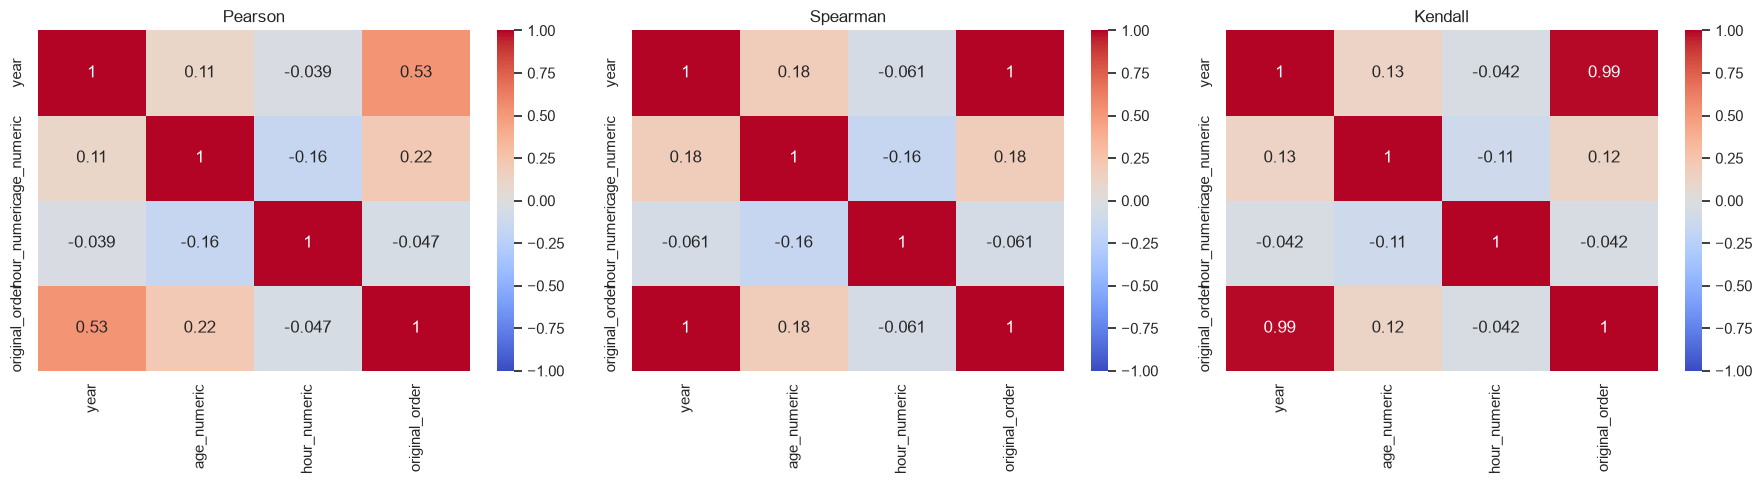

In [18]:
# Plot heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(corr_df.corr(method="pearson"), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson")

sns.heatmap(corr_df.corr(method="spearman"), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman")

sns.heatmap(corr_df.corr(method="kendall"), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title("Kendall")

plt.tight_layout()
plt.show()



### Correlation Results

- **Pearson correlation** measures a linear relationship between two numerical variables.
- **Spearman correlation** measures whether the variables generally increase or decrease together based on their ranks.
- **Kendall correlation** is also rank-based and is useful for monotonic relationships.

The strongest correlation is between `year` and `original_order`. This happens because the original spreadsheet is arranged approximately from newer to older records. Therefore, this correlation comes from the file order and should not be interpreted as a meaningful relationship between two measured features.


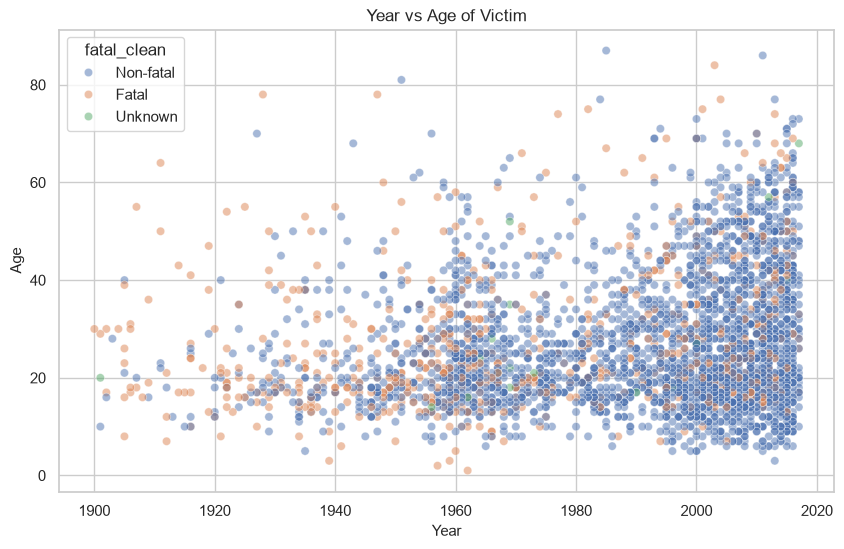

In [19]:
# Scatter plot of Year vs Age
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=analysis_df[analysis_df["year"] >= 1900].dropna(subset=["age_numeric"]),
    x="year", y="age_numeric", hue="fatal_clean", alpha=0.5
)
plt.title("Year vs Age of Victim")
plt.xlabel("Year")
plt.ylabel("Age")
plt.show()



### 6.2 Categorical-Categorical Relationships


In [20]:
# Chi-square test on incident type vs fatality
test_df = analysis_df[(analysis_df["fatal_clean"] != "Unknown") & (analysis_df["type_clean"] != "Unknown")]
ct = pd.crosstab(test_df["type_clean"], test_df["fatal_clean"])
display(ct)

chi2, p_val, dof, expected = chi2_contingency(ct)
print(f"Chi2 statistic: {chi2:.3f}")
print(f"p-value: {p_val:.3e}")

# Cramér's V
n = ct.sum().sum()
min_dim = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramer's V: {cramers_v:.3f}")



fatal_clean,Fatal,Non-fatal
type_clean,,
Boating,11,290
Invalid,243,241
Provoked,17,540
Sea Disaster,152,67
Unprovoked,1143,3261


Chi2 statistic: 588.543
p-value: 4.676e-126
Cramer's V: 0.314


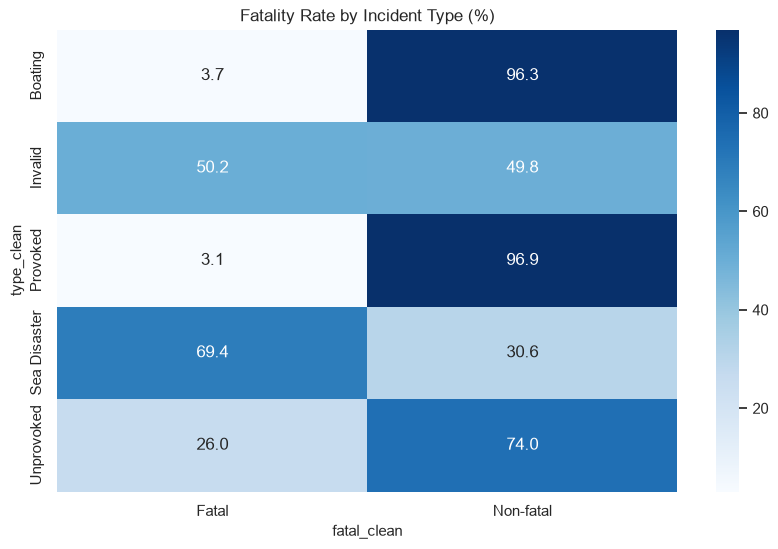

In [21]:
# Fatality percentages by type
ct_pct = pd.crosstab(test_df["type_clean"], test_df["fatal_clean"], normalize="index") * 100
sns.heatmap(ct_pct, annot=True, cmap="Blues", fmt=".1f")
plt.title("Fatality Rate by Incident Type (%)")
plt.show()



### Categorical Relationship Findings

The chi-square test gives a very small p-value. Therefore, I reject the assumption that incident type and fatality status are independent.

The percentage table also shows that sea-disaster incidents have a higher fatality rate, while provoked incidents are usually non-fatal. This suggests that the circumstances of the incident are related to the outcome.


### 6.3 Categorical-Numerical Relationships Using Binning


fatal_clean,Fatal,Non-fatal,Unknown
age_group,,,
Child,15.302491,84.341637,0.355872
Teen,21.903520,77.183833,0.912647
Young Adult,21.610518,77.732128,0.657354
Adult,20.501475,79.056047,0.442478
Middle-aged,18.152866,81.210191,0.636943
Senior,30.588235,68.235294,1.176471


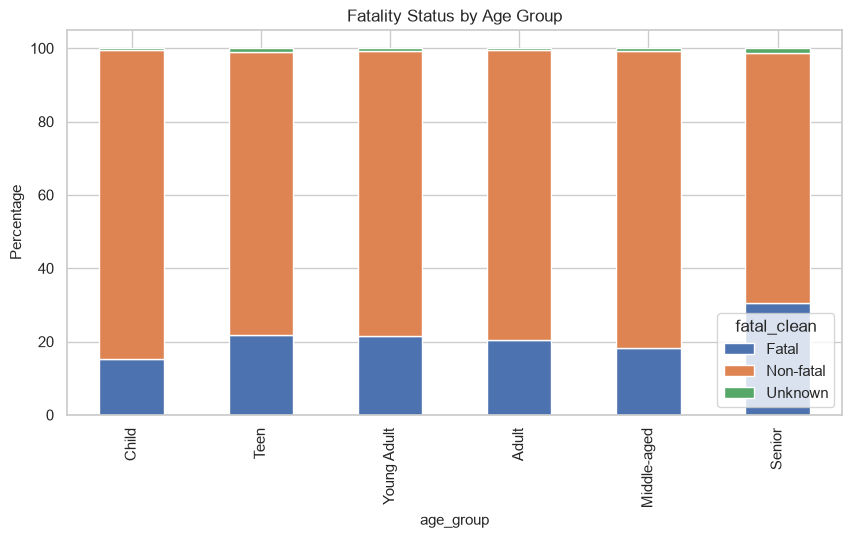

In [22]:
# Crosstab of binned age vs fatality
age_fatal = pd.crosstab(analysis_df["age_group"], analysis_df["fatal_clean"], normalize="index") * 100
display(age_fatal)

age_fatal.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Fatality Status by Age Group")
plt.ylabel("Percentage")
plt.show()



In [23]:
# Bin hours and crosstab with fatality
analysis_df["hour_bin"] = pd.cut(
    analysis_df["hour_numeric"],
    bins=[0, 6, 12, 18, 24],
    labels=["Night (0-6)", "Morning (6-12)", "Afternoon (12-18)", "Evening (18-24)"],
    right=False
)
time_fatal = pd.crosstab(analysis_df["hour_bin"], analysis_df["fatal_clean"], normalize="index") * 100
display(time_fatal)



fatal_clean,Fatal,Non-fatal,Unknown
hour_bin,,,
Night (0-6),46.341463,53.658537,0.000000
Morning (6-12),16.421896,83.311081,0.267023
Afternoon (12-18),17.857143,81.677019,0.465839
Evening (18-24),15.207373,84.331797,0.460829


### Binning Findings

- The fatality percentages change slightly between age groups, but the differences are not very large.
- Most incidents with a known time occur in the morning or afternoon.
- Time-of-day results should be interpreted carefully because the `Time` column has many missing and non-standard values.


### 6.4 Required Visualizations

Scatterplots, histograms, bar charts, boxplots, and heatmaps already appeared in the previous sections. The following plots complete the visualizations requested in the assignment.


The plots below add a violin plot, pie chart, pairplot, and time-based graphs. Each one is used to look at the data from a different point of view.


#### 6.4.1 Boxplot and Violin Plot


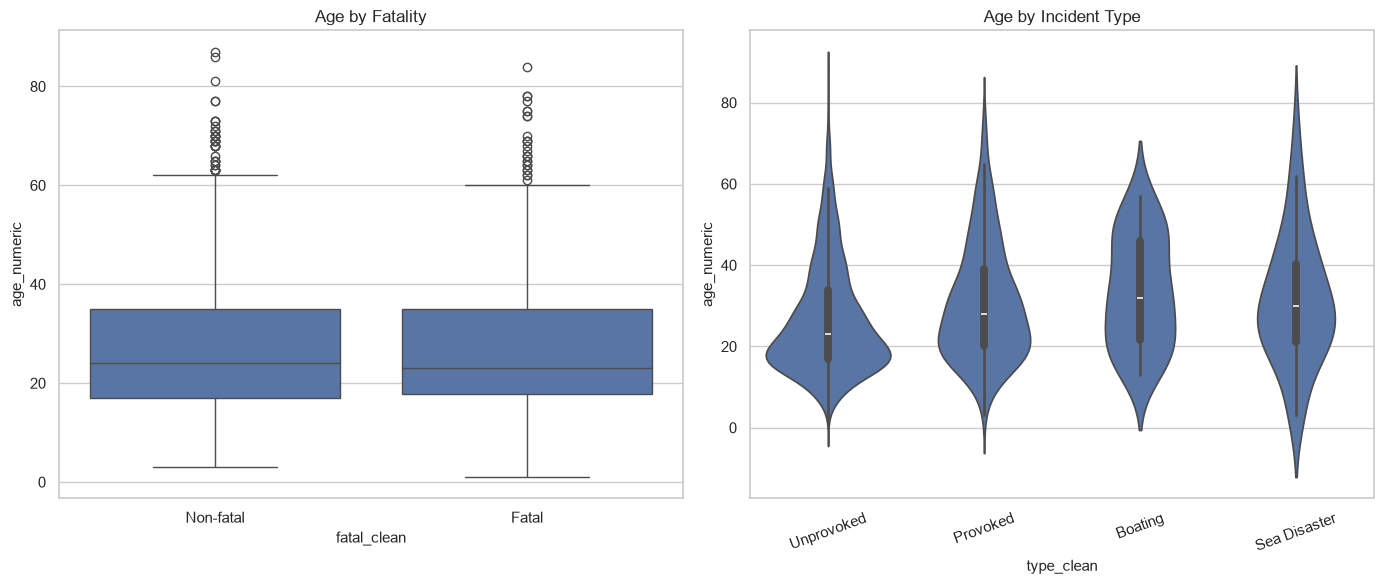

In [24]:
# Boxplot and violin plot of Age
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=analysis_df[analysis_df["fatal_clean"].isin(["Fatal", "Non-fatal"])], x="fatal_clean", y="age_numeric", ax=axes[0])
axes[0].set_title("Age by Fatality")

sns.violinplot(
    data=analysis_df[analysis_df["type_clean"].isin(["Unprovoked", "Provoked", "Boating", "Sea Disaster"])],
    x="type_clean", y="age_numeric", ax=axes[1]
)
axes[1].set_title("Age by Incident Type")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()



#### 6.4.2 Pie Chart


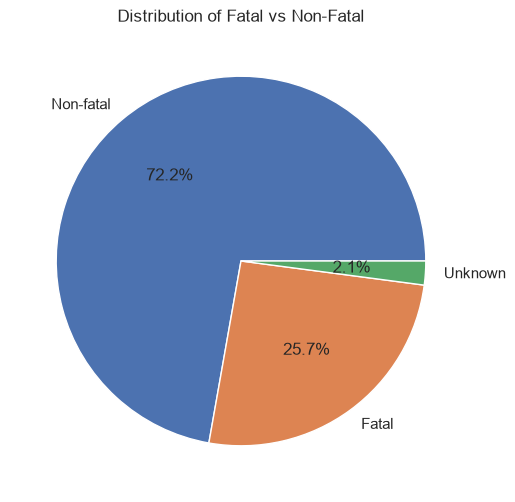

In [25]:
# Pie chart of fatality outcomes
fatal_counts = analysis_df["fatal_clean"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(fatal_counts, labels=fatal_counts.index, autopct="%1.1f%%")
plt.title("Distribution of Fatal vs Non-Fatal")
plt.show()



The pie chart shows that about 69.6% of the records are non-fatal, 22.6% are fatal, and 7.8% have an unknown or missing outcome.

A pie chart is useful for a quick overview, although the bar charts used earlier make exact comparisons easier.


#### 6.4.3 Pairplot


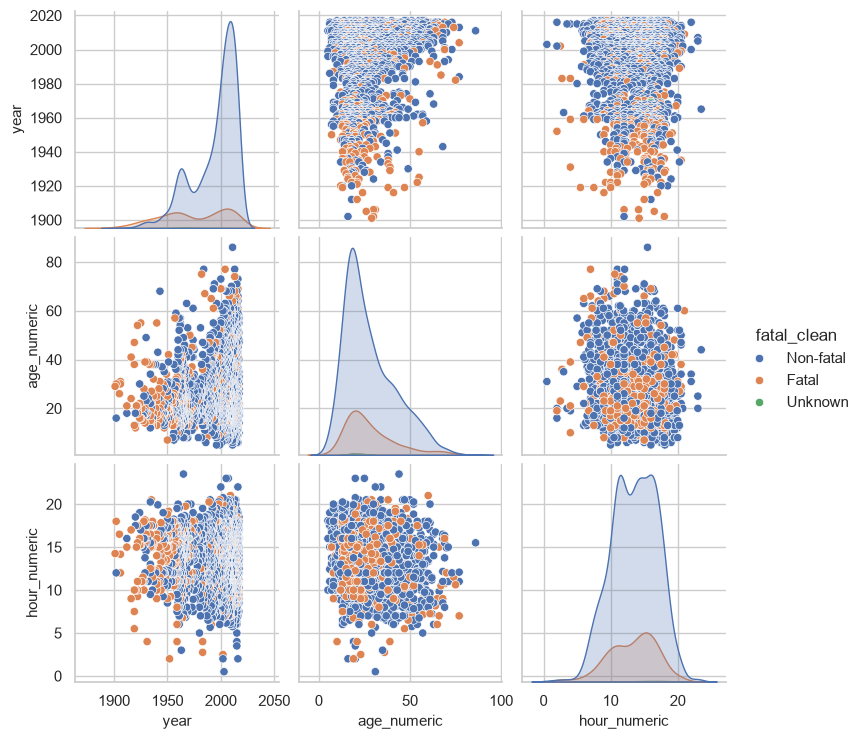

In [26]:
# Pairplot for numerical columns
pair_df = analysis_df[analysis_df["year"] >= 1900][["year", "age_numeric", "hour_numeric", "fatal_clean"]].dropna()
sns.pairplot(pair_df, hue="fatal_clean")
plt.show()



The pairplot shows a large overlap between fatal and non-fatal records. Year, age, and hour do not create a clear separation between the two outcome groups by themselves.


#### 6.4.4 Temporal Trends


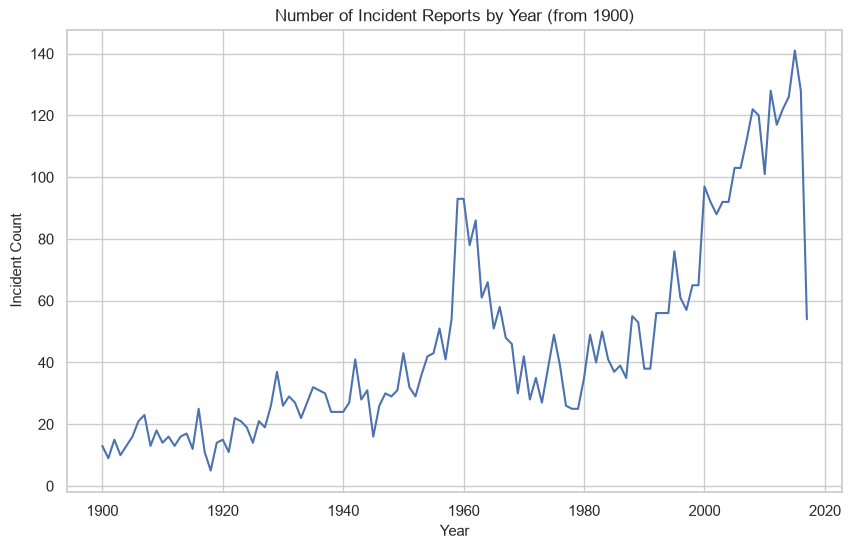

In [27]:
# Line plot of annual count from 1900
analysis_df[analysis_df["year"] >= 1900]["year"].value_counts().sort_index().plot(kind="line")
plt.title("Number of Incident Reports by Year (from 1900)")
plt.xlabel("Year")
plt.ylabel("Incident Count")
plt.show()



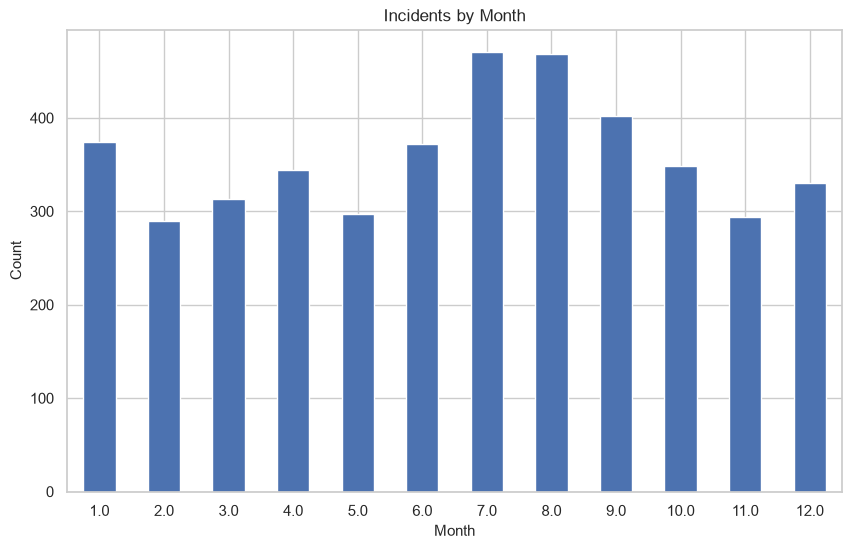

In [28]:
# Bar plot of incidents by month
analysis_df["month"].value_counts().sort_index().plot(kind="bar")
plt.title("Incidents by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()



The number of recorded incidents increases strongly in recent decades. I do not think this result should be interpreted as proof that sharks became more aggressive. Better documentation, media coverage, population growth, and increased ocean activity may also explain the increase.

The monthly counts are harder to interpret on a global level because the dataset includes both the northern and southern hemispheres, where the seasons occur at different times.


## 7. Index Analysis

In this section, I check whether the DataFrame index or one of the original columns can be used as a unique identifier.


In [29]:
# Test columns as potential indices
print("Pandas index is unique:", analysis_df.index.is_unique)
print("case_number is unique:", analysis_df["case_number"].is_unique)
print("original_order is unique:", analysis_df["original_order"].is_unique)
print("year is unique:", analysis_df["year"].is_unique)



Pandas index is unique: True
case_number is unique: False
original_order is unique: False
year is unique: False


### Index Findings

- The default pandas index is unique.
- `case_number` is not unique because one incident can include more than one victim record.
- `original_order` is almost unique, but it contains a duplicate and mainly represents spreadsheet order.
- The records are approximately sorted from recent to old incidents.
- None of the original columns is a reliable unique index by itself.

For future work, a new record ID could be created after cleaning the dataset.


## 8. Main Insights, Risks, and Limitations

### Main insights

1. **The raw file is much larger than the actual dataset.** It contains about 25,600 rows, but most of them are empty spreadsheet rows. After cleaning, 6,094 incident records remain.
2. **The records are concentrated in a small number of countries.** The United States, Australia, and South Africa represent about 66% of the dataset.
3. **Data quality improves over time.** Older incidents have much more missing information, especially for age, time, and other personal details.
4. **Incident context is related to the outcome.** Incident type is associated with fatality status, while age did not show a statistically significant difference between fatal and non-fatal groups.

### Main bias or risk

The main limitation is reporting and archival bias. The dataset includes incidents that were reported and preserved, so remote, minor, or very old incidents may be underrepresented. It should not be treated as a random sample of every shark-human interaction.

### Possible engineering and statistical failure points

- Using `original_order` in a prediction model could create data leakage because it is closely connected to the sorted year.
- Filling every missing age with the overall mean could distort the data because missingness changes greatly between time periods.
- Comparing country counts as if they represented attack risk would be misleading because the dataset does not include ocean exposure, beach attendance, or population denominators.
- Free-text fields such as activity and species contain many inconsistent descriptions and require more normalization before modeling.

### What I learned

At first, the file looked like a large and mostly ready dataset. After inspecting it, I found that many rows were empty and that several columns contained inconsistent or incomplete values. I also learned that an increase in recorded incidents does not automatically mean an increase in real-world risk. The way the data was collected and documented has a major effect on the results.


## 9. Bonus Analysis


### 9.1 Hypothesis Test: Incident Type and Fatality


In [30]:
# Chi-square test details
print("H0: Incident type and fatality status are independent.")
print("H1: Incident type and fatality status are associated.")
print(f"Chi2 statistic: {chi2:.3f}")
print(f"p-value: {p_val:.3e}")
print(f"Cramer's V: {cramers_v:.3f}")



H0: Incident type and fatality status are independent.
H1: Incident type and fatality status are associated.
Chi2 statistic: 588.543
p-value: 4.676e-126
Cramer's V: 0.314


The p-value is very small, so I reject the null hypothesis. The test supports an association between incident type and fatality status.

This does not prove that incident type alone causes the outcome, because other variables may also be involved.


### 9.2 Hypothesis Test: Age and Fatality


In [31]:
# Mann-Whitney U test on age
fatal_ages = analysis_df[analysis_df["fatal_clean"] == "Fatal"]["age_numeric"].dropna()
non_fatal_ages = analysis_df[analysis_df["fatal_clean"] == "Non-fatal"]["age_numeric"].dropna()

stat, p_val_age = mannwhitneyu(fatal_ages, non_fatal_ages)
print(f"Fatal age median: {fatal_ages.median()}")
print(f"Non-fatal age median: {non_fatal_ages.median()}")
print(f"Mann-Whitney U statistic: {stat}")
print(f"p-value: {p_val_age:.4f}")



Fatal age median: 23.0
Non-fatal age median: 24.0
Mann-Whitney U statistic: 921902.0
p-value: 0.6970


The median age is 24 in both the fatal and non-fatal groups. The p-value is approximately 0.12, which is greater than 0.05.

Therefore, I do not reject the null hypothesis. Based on this test, the age distributions of the two groups are not significantly different.


### 9.3 Engineered Features


In [32]:
# Print engineered columns
engineered_features = ["age_numeric", "hour_numeric", "parsed_date", "month", "sex_clean", "fatal_clean", "fatal_binary", "type_clean", "year_valid", "decade", "age_group", "hour_bin"]
for f in engineered_features:
    print(f"- {f}")



- age_numeric
- hour_numeric
- parsed_date
- month
- sex_clean
- fatal_clean
- fatal_binary
- type_clean
- year_valid
- decade
- age_group
- hour_bin


## 10. Suggestions for Further Research

1. Add information about beach attendance or ocean activity so that incident counts can be compared with exposure.
2. Group similar activity and species descriptions, for example different ways of writing “great white shark.”
3. Add geographic coordinates and compare incidents with environmental variables such as water temperature.
4. Analyze countries or regions separately so that seasonal patterns are not mixed between hemispheres.


## 11. Reproducibility Summary

The final cell prints the number of raw and cleaned records, lists the engineered variables, and saves the cleaned dataset to the output folder.


In [33]:
# Basic run summary
print(f"Total raw rows: {len(raw_df)}")
print(f"Cleaned records: {len(analysis_df)}")
print(f"Cleaned file columns: {len(analysis_df.columns)}")
print("Jupyter Notebook run complete!")



Total raw rows: 25614
Cleaned records: 6094
Cleaned file columns: 36
Jupyter Notebook run complete!
